# Summary Scores

## Load Models

In [24]:
import torch
import pandas as pd
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bart_id = "facebook/bart-large-cnn"
model1_id = "Veekee/cmpe-252-summary-project"
model2_id = "../models/checkpoint-11619"

bart_tokenizer = AutoTokenizer.from_pretrained(bart_id)
bart_model = AutoModelForSeq2SeqLM.from_pretrained(bart_id).to(device)

model1_tokenizer = AutoTokenizer.from_pretrained(model1_id)
model1_model = AutoModelForSeq2SeqLM.from_pretrained(model1_id).to(device)

model2_tokenizer = AutoTokenizer.from_pretrained(model2_id)
model2_model = AutoModelForSeq2SeqLM.from_pretrained(model2_id).to(device)

Loading weights: 100%|██████████| 511/511 [00:00<00:00, 1183.27it/s, Materializing param=model.encoder.layers.11.self_attn_layer_norm.weight]   
BartForConditionalGeneration LOAD REPORT from: facebook/bart-large-cnn
Key                               | Status  | 
----------------------------------+---------+-
lm_head.weight                    | MISSING | 
final_logits_bias                 | MISSING | 
model.shared.weight               | MISSING | 
model.encoder.embed_tokens.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


KeyboardInterrupt: 

## Upload Test Dataset

In [ ]:
from datasets import Dataset

test_df = pd.read_parquet("../data/test_data.parquet")

test_dataset = Dataset.from_pandas(test_df)

## Generate Summary

In [ ]:
def generate_summary(text, model, tokenizer):  
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=1024)

    with torch.no_grad():
        summary_ids = model.generate(
            inputs["input_ids"],
            num_beams=4,
            max_length=128,
            min_length=30,
            no_repeat_ngram_size=3, # prevents loops
            length_penalty=2.0,     # standard penalty
            early_stopping=True
        )

    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

## Generate Summary and Score Summaries

Each model generates their summaries and scores based on each summary compared to the reference

In [ ]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
results = []

for sample in tqdm(test_dataset.select(range(5))):
    source = sample['article']
    reference = sample['abstract']

    bart_summary = generate_summary(source, bart_model, bart_tokenizer)
    model1_summary = generate_summary(source, model1_model, model1_tokenizer)
    model2_summary = generate_summary(source, model2_model, model2_tokenizer)

    bart_scores = scorer.score(reference, bart_summary)
    model1_scores = scorer.score(reference, model1_summary)
    model2_scores = scorer.score(reference, model2_summary)

    bart_cr = len(bart_summary.split()) / len(source.split())
    model1_cr = len(model1_summary.split()) / len(source.split())
    model2_cr = len(model2_summary.split()) / len(source.split())

    bart_density = bart_scores['rougeL'].fmeasure / (bart_cr + 1e-9)
    model1_density = model1_scores['rougeL'].fmeasure / (model1_cr + 1e-9)
    model2_density = model2_scores['rougeL'].fmeasure / (model2_cr + 1e-9)

    results.append({
        "bart_summary": bart_summary,
        "model1_summary": model1_summary,
        "model2_summary": model2_summary,
        "bart_r1": bart_scores['rouge1'].fmeasure,
        "model1_r1": model1_scores['rouge1'].fmeasure,
        "model2_r1": model2_scores['rouge1'].fmeasure,
        "bart_r2": bart_scores['rouge2'].fmeasure,
        "model1_r2": model1_scores['rouge2'].fmeasure,
        "model2_r2": model2_scores['rouge2'].fmeasure,
        "bart_rL": bart_scores['rougeL'].fmeasure,
        "model1_rL": model1_scores['rougeL'].fmeasure,
        "model2_rL": model2_scores['rougeL'].fmeasure,
        "bart_cr": bart_cr,
        "model1_cr": model1_cr,
        "model2_cr": model2_cr,
        "bart_density": bart_density,
        "model1_density": model1_density,
        "model2_density": model2_density
    })

df_results = pd.DataFrame(results)
df_results.head()

100%|██████████| 5/5 [03:34<00:00, 42.88s/it]


,bart_summary,model1_summary,model2_summary,bart_r1,model1_r1,model2_r1,bart_r2,model1_r2,model2_r2,bart_rL,model1_rL,model2_rL,bart_cr,model1_cr,model2_cr,bart_density,model1_density,model2_density
0,The problem of properties of short - term chan...,a new method of the diagnosis of an echo - eff...,we present a new approach to the problem of th...,0.281250,0.418118,0.392027,0.102362,0.175439,0.127090,0.179688,0.236934,0.199336,0.010285,0.018341,0.019026,17.471613,12.918427,10.476789
1,It is believed that the direct detection of gr...,we investigate the detectability of circular p...,we investigate the detectability of circular p...,0.358209,0.473988,0.500000,0.136364,0.269006,0.252874,0.253731,0.404624,0.375000,0.007049,0.014710,0.015170,35.996750,27.506019,24.719695
2,The tunneling through a potential barrier play...,a new formula for the barrier penetrability of...,we have derived a new barrier penetration form...,0.285714,0.596273,0.571429,0.057971,0.389937,0.366667,0.214286,0.447205,0.318681,0.023762,0.032622,0.043496,9.018159,13.708764,7.326719
3,The hybrid monte carlo algorithm ( hmc)@xcite ...,we present a new class of numerical time integ...,we study the behavior of numerical time integr...,0.559524,0.543210,0.441860,0.156627,0.175000,0.141176,0.226190,0.296296,0.267442,0.027360,0.027360,0.029822,8.267262,10.829629,8.967890
4,In the present paper we propose essentially ne...,in this paper we propose essentially new metho...,we propose essentially new methods for derivin...,0.304878,0.391753,0.405797,0.098765,0.166667,0.136585,0.182927,0.257732,0.241546,0.012318,0.020381,0.023516,14.850331,12.645859,10.271451


## Create Table to Compare All Scores

In [25]:
comparison_table = df_results[["bart_r1","bart_r2","bart_rL","model1_r1", "model1_r2", "model1_rL","model2_r1","model2_r2","model2_rL","bart_cr","model1_cr","model2_cr","bart_density","model1_density","model2_density"]].mean().to_frame(name="Average Scores")

display(comparison_table)

,Average Scores
bart_r1,0.357915
bart_r2,0.110418
bart_rL,0.211364
model1_r1,0.484669
model1_r2,0.235210
model1_rL,0.328558
model2_r1,0.462223
model2_r2,0.204878
model2_rL,0.280401
bart_cr,0.016155


In [ ]:
results_parquet_path = "../results/all_results.parquet"
df_results.to_parquet(results_parquet_path, index=False)

comparison_parquet_path = "../results/comparison_table.parquet"
comparison_table.to_parquet(comparison_parquet_path)

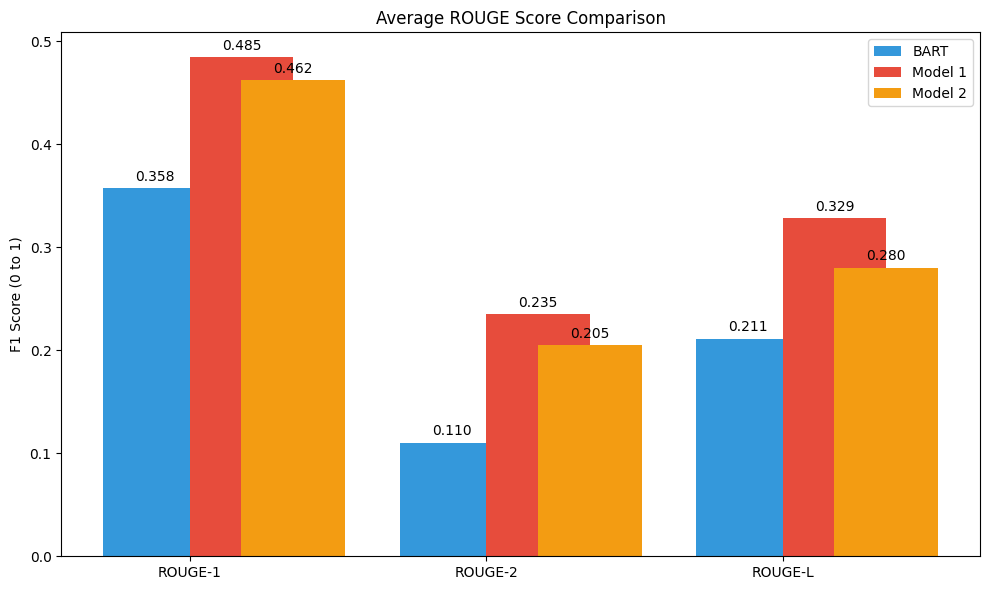

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate averages for all metrics
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
bart_means = [
    df_results['bart_r1'].mean(), 
    df_results['bart_r2'].mean(), 
    df_results['bart_rL'].mean()
]
model1_means = [
    df_results['model1_r1'].mean(), 
    df_results['model1_r2'].mean(), 
    df_results['model1_rL'].mean()
]
model2_means = [
    df_results['model2_r1'].mean(), 
    df_results['model2_r2'].mean(), 
    df_results['model2_rL'].mean()
]

# 2. Set up the bar locations
x = np.arange(len(metrics))
width = 0.35

# 3. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/3, bart_means, width, label='BART', color='#3498db')
rects2 = ax.bar(x + width/2, model1_means, width, label='Model 1', color='#e74c3c')
rects3 = ax.bar(x + width, model2_means, width, label='Model 2', color='#f39c12')

# 4. Add labels and styling
ax.set_ylabel('F1 Score (0 to 1)')
ax.set_title('Average ROUGE Score Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# 5. Add text labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.savefig('../results/rouge_comparison_chart.png')
plt.show()

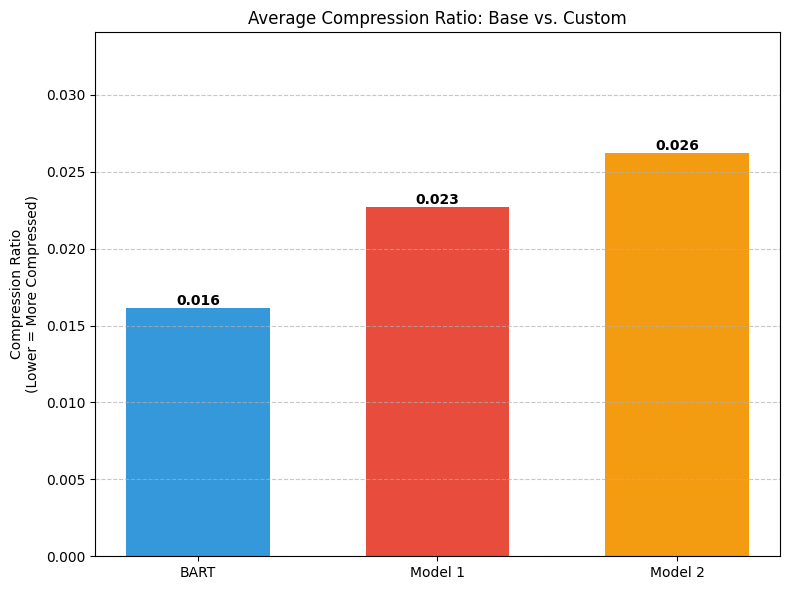

In [ ]:
import matplotlib.pyplot as plt

# 1. Calculate the means
bart_cr_mean = df_results['bart_cr'].mean()
model1_cr_mean = df_results['model1_cr'].mean()
model2_cr_mean = df_results['model2_cr'].mean()

# 2. Create the Bar Chart
plt.figure(figsize=(8, 6))
models = ['BART', 'Model 1', 'Model 2']
means = [bart_cr_mean, model1_cr_mean, model2_cr_mean]
colors = ['#3498db', '#e74c3c', '#f39c12']

bars = plt.bar(models, means, color=colors, width=0.6)

# 3. Add Labels and Styling
plt.ylabel('Compression Ratio\n(Lower = More Compressed)')
plt.title('Average Compression Ratio: Base vs. Custom')
plt.ylim(0, max(means) * 1.3) # Add space for labels

# Add the values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../results/compression_ratio_comparison_chart.png')
plt.show()

/var/folders/60/b5613ft91lj31zhgk9phb9hr0000gn/T/ipykernel_14200/3659054323.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Compression Ratio', data=plot_df, palette=['#3498db', '#e74c3c', '#f39c12'])


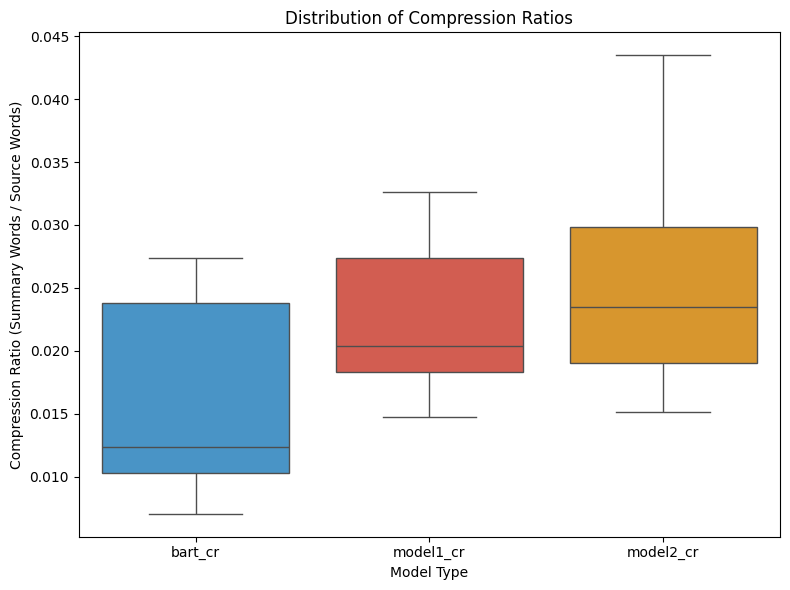

In [ ]:
import seaborn as sns

# 1. Prepare data for Seaborn (Long format)
plot_df = df_results.melt(value_vars=['bart_cr', 'model1_cr', 'model2_cr'], 
                          var_name='Model', 
                          value_name='Compression Ratio')

# 2. Create the Box Plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Model', y='Compression Ratio', data=plot_df, palette=['#3498db', '#e74c3c', '#f39c12'])

# 3. Add Labels
plt.title('Distribution of Compression Ratios')
plt.ylabel('Compression Ratio (Summary Words / Source Words)')
plt.xlabel('Model Type')

plt.tight_layout()
plt.savefig('../results/compression_distribution_box.png')
plt.show()

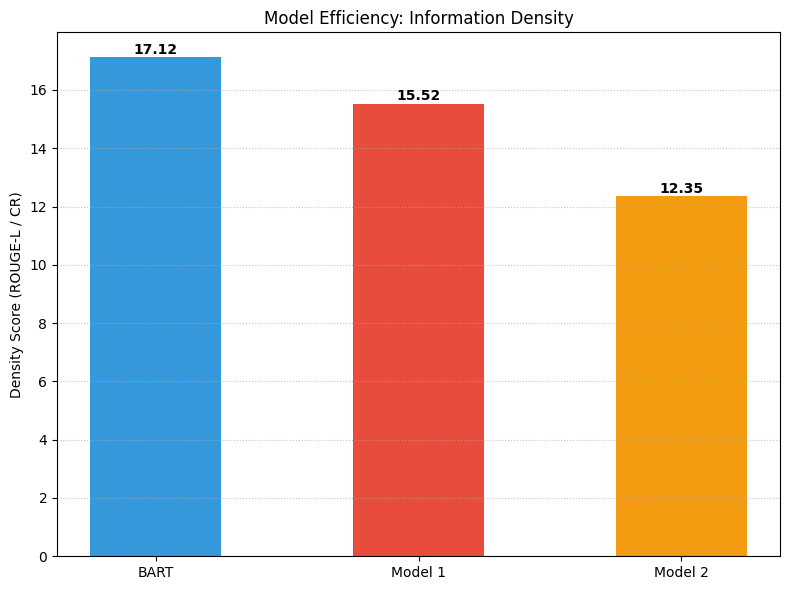

In [ ]:
# 1. Calculate the mean density
bart_density_mean = df_results['bart_density'].mean()
model1_density_mean = df_results['model1_density'].mean()
model2_density_mean = df_results['model2_density'].mean()

# 2. Plotting
plt.figure(figsize=(8, 6))
labels = ['BART', 'Model 1', 'Model 2']
densities = [bart_density_mean, model1_density_mean, model2_density_mean]
colors = ['#3498db', '#e74c3c', '#f39c12']

bars = plt.bar(labels, densities, color=colors, width=0.5)

# 3. Styling
plt.ylabel('Density Score (ROUGE-L / CR)')
plt.title('Model Efficiency: Information Density')
plt.grid(axis='y', linestyle=':', alpha=0.7)

# Add numeric labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.2f}', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/information_density_comparison_chart.png')
plt.show()

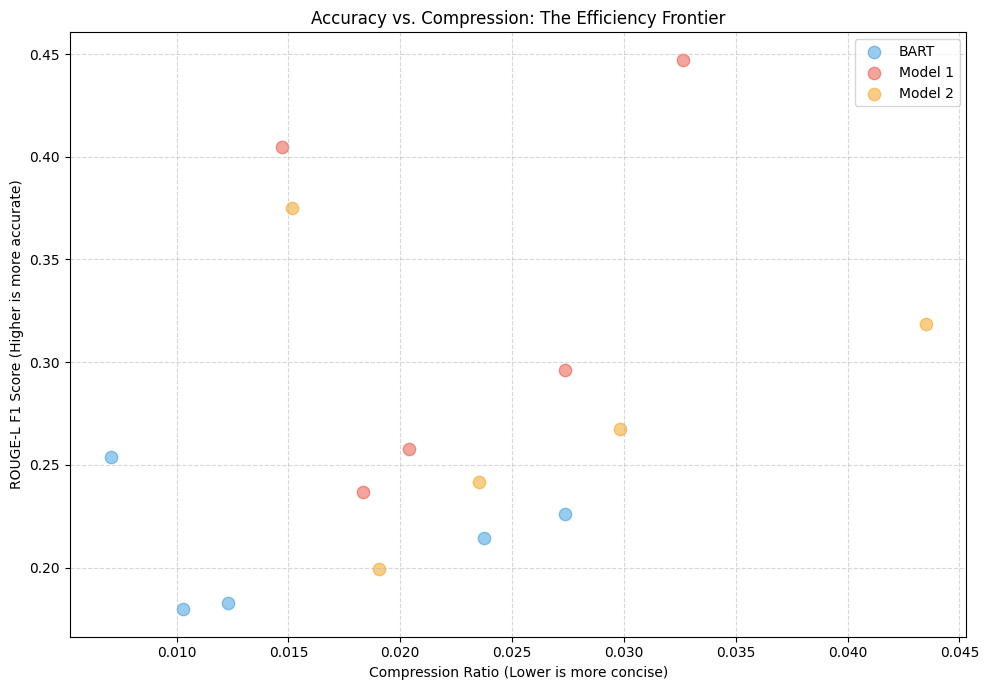

In [ ]:
plt.figure(figsize=(10, 7))

# Plot Base Model samples
plt.scatter(df_results['bart_cr'], df_results['bart_rL'], 
            alpha=0.5, label='BART', color='#3498db', s=80)

# Plot Custom Model samples
plt.scatter(df_results['model1_cr'], df_results['model1_rL'], 
            alpha=0.5, label='Model 1', color='#e74c3c', s=80)

plt.scatter(df_results['model2_cr'], df_results['model2_rL'], 
            alpha=0.5, label='Model 2', color='#f39c12', s=80)

# Add "Target Zone" Annotation
plt.annotate('Highest Efficiency Zone', xy=(0.1, 0.5), xytext=(0.25, 0.6),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             fontsize=10, fontweight='bold')

# Styling
plt.xlabel('Compression Ratio (Lower is more concise)')
plt.ylabel('ROUGE-L F1 Score (Higher is more accurate)')
plt.title('Accuracy vs. Compression: The Efficiency Frontier')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../results/accuracy_compression_scatter.png')
plt.show()